# PyTorch Primer for Keras Users: MNIST CNN Side-by-Side

This notebook is chapter **00** of the GenAI learning track -- a primer to run _before_
`01-rnns/`. The chapters ahead mix TensorFlow/Keras and PyTorch notebooks (see
`01-rnns/MIT/TF_Part1_Intro-keras.ipynb` vs. `PT_Part1_Intro.ipynb`), so if you know Keras
well but haven't written raw PyTorch before, this closes that gap with the smallest useful
example: **the same CNN digit classifier, built twice, cell by cell.**

**How to use this notebook:** each section has a short explanation, then a **Keras cell**
immediately followed by the **equivalent PyTorch cell**, doing the exact same job. Run them
in order -- by the end you'll have two independently trained models on the same MNIST data.

## What you'll build

A small convolutional network for MNIST digit classification, in both frameworks:

```
Conv2D(32, 3x3) -> MaxPool(2x2) -> Conv2D(64, 3x3) -> MaxPool(2x2) -> Flatten -> Dense(128) -> Dense(10)
```

## What you'll be able to do when done

- Translate a Keras `Sequential` model into a PyTorch `nn.Module` and back
- Explain the five biggest structural differences between the two frameworks (see the
  cheat-sheet at the end)
- Write a PyTorch training loop from scratch, instead of relying on `model.fit()`
- Know the channel-order (NHWC vs. NCHW), device-placement, and train/eval-mode gotchas that
  trip up Keras users switching to PyTorch


## Table of Contents

1. [Roadmap](#roadmap)
   - [Topic Map -- The Full Keras<->PyTorch Space, at a Glance](#topic-map-the-full-keraspytorch-space-at-a-glance)
2. [Section 1: Imports & Seeding](#section-1-imports-seeding)
3. [Section 2: Loading MNIST](#section-2-loading-mnist)
   - [The gotcha you'll hit immediately: NHWC vs. NCHW](#the-gotcha-youll-hit-immediately-nhwc-vs-nchw)
4. [Section 3: Defining the Model](#section-3-defining-the-model)
   - [Inspecting the model](#inspecting-the-model)
5. [Section 4: Compile vs. Loss + Optimizer](#section-4-compile-vs-loss-optimizer)
6. [Section 5: Training](#section-5-training)
   - [Code Walkthrough: The Four-Step PyTorch Training Loop](#code-walkthrough-the-four-step-pytorch-training-loop)
   - [Proving train()/eval() actually changes behavior](#proving-traineval-actually-changes-behavior)
7. [Section 6: Evaluation](#section-6-evaluation)
8. [Section 7: Inference / Prediction](#section-7-inference-prediction)
9. [Saving and Loading Weights](#saving-and-loading-weights)
10. [Cheat Sheet: Keras -> PyTorch](#cheat-sheet-keras---pytorch)
    - [Gotchas worth remembering](#gotchas-worth-remembering)
    - [Next steps](#next-steps)
11. [What This Notebook Covered (and What It Didn't)](#what-this-notebook-covered-and-what-it-didnt)
12. [Roadmap -- completed](#roadmap----completed)

> Links jump to the matching heading below. If a link doesn't scroll correctly in your Jupyter
> viewer, use `Ctrl+F` / the notebook outline panel with the section title instead.



## Roadmap

| Step | Concept | Key Idea |
|---|---|---|
| 1 | Imports & seeding | No "backend" in PyTorch -- `torch` *is* the library; reproducibility is one `manual_seed` call |
| 2 | Loading MNIST | Keras hands you NumPy arrays; PyTorch wraps data in `Dataset` + `DataLoader` -- and the channel axis moves from last to first |
| 3 | Defining the model | Keras infers every shape from `Input`; PyTorch makes you compute and hard-code the flattened feature-map size yourself |
| 4 | Compile vs. loss + optimizer | Keras bundles optimizer/loss/metrics into `compile()`; PyTorch just gives you two plain objects |
| 5 | Training | Keras hides the loop in `.fit()`; PyTorch makes every step -- `zero_grad -> forward -> backward -> step` -- explicit, including the gradient-accumulation gotcha if you skip one |
| 6 | Evaluation | Keras runs `.evaluate()`; PyTorch needs `model.eval()` + `torch.no_grad()` around a manual loop |
| 7 | Inference / prediction | Keras returns probabilities from `.predict()`; PyTorch returns raw logits you `argmax()` yourself |
| -- | Saving/loading + cheat sheet + gotchas | `state_dict()` vs. `model.save()`, every Keras call mapped to its PyTorch equivalent, plus the seven mistakes that trip up Keras users first |

By the end, both models will have been trained independently on the same MNIST data --
the closing section checks that they actually land on comparable test accuracy, not just
that the code compiles.



## Topic Map — The Full Keras↔PyTorch Space, at a Glance

This primer builds 9 Keras/PyTorch pairs side by side, from seeding through saving weights.
A few more ideas -- `nn.Dropout`'s train/eval switch, `nn.Sequential` -- get a quick
illustration along the way. A handful of related topics -- custom `Dataset` subclasses, data
augmentation, LR schedulers/callbacks, deployment export -- are named but intentionally out
of scope; see the closing
**[What This Notebook Covered (and What It Didn't)](#what-this-notebook-covered-and-what-it-didnt)**
recap for the full list.


## Section 1: Imports & Seeding

**Keras:** TensorFlow is the backend; `tf.random.set_seed` plus `np.random.seed` covers
reproducibility. TensorFlow 2.x runs eagerly by default -- no separate "graph mode" step
needed anywhere in this notebook.

**PyTorch:** There's no framework-level "backend" -- `torch` _is_ the library you import
directly. Reproducibility is one call: `torch.manual_seed`. PyTorch is eager by default too,
but unlike Keras there is no automatic device placement: you will see explicit `.to(device)`
calls throughout this notebook, because tensors and models don't move to a GPU unless you
tell them to.


In [1]:
# --- Keras ---
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available (Keras):", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.21.0


GPU available (Keras): False


In [2]:
# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device (PyTorch):", device)

PyTorch version: 2.13.0+cpu
Device (PyTorch): cpu


## Section 2: Loading MNIST

**Keras:** `keras.datasets.mnist` hands you plain NumPy arrays -- `(x_train, y_train),
(x_test, y_test)` -- already split into train/test. No `Dataset`/`DataLoader` concept; you
pass the arrays straight into `model.fit()` later.

**PyTorch:** there's no bundled dataset module as convenient as `keras.datasets`; instead
`torchvision.datasets.MNIST` downloads and wraps the data as a `Dataset`, and you wrap _that_
in a `DataLoader` to get batching, shuffling, and iteration for free. This two-layer
abstraction (`Dataset` + `DataLoader`) is the PyTorch-native way to feed data to a training
loop, and you'll see it reused for any custom dataset later in this track.


### 🔮 Predict first

Before you run the Keras and PyTorch loading cells further down: both frameworks load the
exact same 60,000 training images. Each one will print the shape of a single image tensor
after loading.

- What shape do you think **Keras** will print for one image? (Hint: think "channels last".)
- What shape do you think **PyTorch** will print for the same image? (Hint: think "channels first".)
- Will the two shapes even list the same three dimensions in the same order?

Run the Keras cell, then the PyTorch cell, and compare the printed shapes against your guess.


In [3]:
# --- Keras ---
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add the channel dimension LAST -> shape (N, 28, 28, 1)
x_train = np.expand_dims(x_train.astype("float32") / 255.0, -1)
x_test = np.expand_dims(x_test.astype("float32") / 255.0, -1)

print("x_train:", x_train.shape, "| y_train:", y_train.shape)
print("x_test: ", x_test.shape, " | y_test: ", y_test.shape)


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


  425984/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


 3809280/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


x_train: (60000, 28, 28, 1) | y_train: (60000,)
x_test:  (10000, 28, 28, 1)  | y_test:  (10000,)


In [4]:
# --- PyTorch ---
# ToTensor() scales to [0, 1] AND puts the channel dimension FIRST -> shape (1, 28, 28)
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# .data is the raw, untransformed tensor (no channel dim yet); indexing the dataset applies
# `transform` and is what the DataLoader actually feeds the model, so that's the shape that matters.
sample_image, sample_label = train_dataset[0]
print(
    "train_dataset:",
    len(train_dataset),
    "images | one transformed sample:",
    sample_image.shape,
)
print("test_dataset: ", len(test_dataset), "images")


0.3%


0.7%


1.0%


1.3%


1.7%

...


97.4%


99.4%


100.0%


100.0%

train_dataset: 60000 images | one transformed sample: torch.Size([1, 28, 28])
test_dataset:  10000 images


### The gotcha you'll hit immediately: NHWC vs. NCHW

Look closely at the two shapes printed above: Keras gave you `(28, 28, 1)` per image
(**channels last**), PyTorch gave you `(1, 28, 28)` (**channels first**). This isn't a typo
-- it's a real, silent bug magnet. If you ever port a Keras preprocessing pipeline to
PyTorch (or vice versa) and forget to transpose, your convolution will either crash on a
shape mismatch or, worse, silently run on the wrong axis. `torchvision.transforms.ToTensor()`
already does this conversion for you, which is exactly why it's used above instead of a raw
NumPy-to-tensor cast.


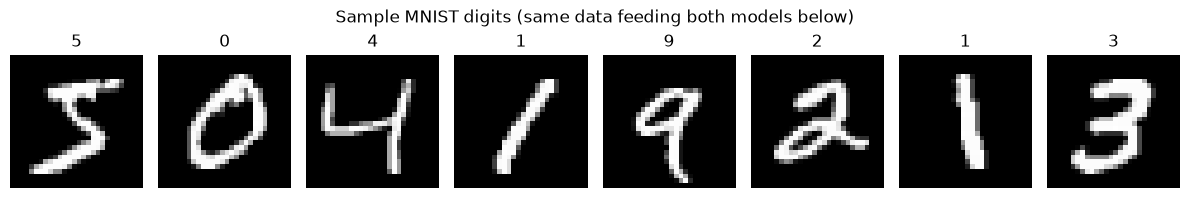

In [5]:
# Shared visualization -- both frameworks are looking at the same underlying MNIST digits
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample MNIST digits (same data feeding both models below)")
plt.tight_layout()
plt.show()

## Section 3: Defining the Model

**Keras:** `keras.Sequential` lists layers in order. You only need to declare the _input_
shape once (via `keras.Input`); every layer after that infers its input size automatically
-- including the flattened size going into the first `Dense` layer.

**PyTorch:** a model is a Python class that subclasses `nn.Module`. You declare every layer
in `__init__` (each with an explicit `in_channels`/`in_features`) and then write the
**forward pass yourself** as ordinary Python code in `forward()`. Nothing is inferred: the
comment below shows the exact arithmetic for why `64 * 5 * 5` is the flattened size feeding
`fc1` -- get this number wrong and you get a shape-mismatch error at the first `forward()`
call, not at model-definition time.


In [ ]:
# --- Keras ---
keras_model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
print("Keras Sequential defined — Flatten() + Dense() infer the flattened size automatically.")
print(f"Total parameters: {keras_model.count_params():,} (Keras counted them for you via shape inference).")


### 🔮 Predict first

The Keras model you defined just above never mentions a flattened size -- `Flatten()` +
the first `Dense` layer figure it out automatically. The PyTorch `SimpleCNN` class further
down will *not* have that luxury: you have to compute the flattened feature count by hand
and hard-code it into `nn.Linear`.

Starting from a 28x28 input with **no padding**:
- `Conv2d(kernel_size=3)` shrinks each spatial dimension by 2 (28 -> 26).
- `MaxPool2d(kernel_size=2)` halves it (26 -> 13).
- A second `Conv2d(kernel_size=3)` shrinks it by 2 again (13 -> 11).
- A second `MaxPool2d(kernel_size=2)` halves it again, rounding down (11 -> 5).

Before reading the code: what do you think the final flattened feature count is, given the
last conv layer has **64** output channels? Write down a number, then check it against the
comment in the `SimpleCNN` class further down -- and against the measured shapes in the
dummy-forward-pass verification further down.


In [ ]:
# --- PyTorch ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # 28 -> conv3x3 -> 26 -> pool2 -> 13 -> conv3x3 -> 11 -> pool2 -> 5 (floor)
        # so the flattened feature map is 64 channels x 5 x 5 = 1600 -- computed BY HAND,
        # not inferred, which is the single biggest day-to-day difference from Keras.
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten every dim except the batch dim
        x = F.relu(self.fc1(x))
        return self.fc2(
            x
        )  # raw logits -- softmax is applied inside the loss function later


With the class defined, instantiate it and move it to `device` -- this is also where
Keras's automatic `.summary()` parameter count gets replaced with a plain generator
expression over `model.parameters()`.


In [ ]:
pytorch_model = SimpleCNN().to(device)
n_params = sum(p.numel() for p in pytorch_model.parameters())
print(f"PyTorch SimpleCNN: {n_params:,} parameters on {device}.")
print("Unlike Keras, the 64*5*5 flatten size was computed BY HAND — get it wrong and")
print("you get a RuntimeError on the first forward() call, not at model-definition time.")


In [8]:
# --- Verify the hand-computed flatten size, don't just trust the comment ---
# Same conv/pool stack as SimpleCNN.forward(), run step-by-step on a dummy batch so the
# shapes are MEASURED, not asserted.
dummy = torch.zeros(1, 1, 28, 28).to(device)

with torch.no_grad():
    step1 = pytorch_model.pool1(F.relu(pytorch_model.conv1(dummy)))
    step2 = pytorch_model.pool2(F.relu(pytorch_model.conv2(step1)))
    flattened = step2.view(step2.size(0), -1)

print("after conv1 + pool1:", tuple(step1.shape))
print("after conv2 + pool2:", tuple(step2.shape))
print("flattened:          ", tuple(flattened.shape))

expected = 64 * 5 * 5
measured = flattened.shape[1]
print(f"\nHard-coded in fc1: {expected} | Measured by running data through the layers: {measured}")
assert measured == expected, "The hard-coded flatten size no longer matches the model -- fix nn.Linear's in_features."
print("-> Match confirmed: the hand-computed 64*5*5 comment was correct.")


after conv1 + pool1: (1, 32, 13, 13)
after conv2 + pool2: (1, 64, 5, 5)
flattened:           (1, 1600)

Hard-coded in fc1: 1600 | Measured by running data through the layers: 1600
-> Match confirmed: the hand-computed 64*5*5 comment was correct.


#### What just happened

The flattened size wasn't just claimed in a comment -- it was measured by actually running
a dummy image through every conv/pool layer and reading `.shape` off the result. That's the
habit to keep: any time you hard-code a PyTorch shape, add a one-off dummy forward pass like
the one above to catch a wrong number at authoring time instead of at the first real
`forward()` call. Keras never needs this because `Input(shape=...)` lets every later layer
infer its own size.



### 🧪 Your turn -- change the conv stack and recompute the flatten size

🔮 **Predict first:** if you add `padding=1` to both `nn.Conv2d` layers (so each conv
**preserves** spatial size instead of shrinking it, since a 3x3 kernel with 1 pixel of
padding on every side keeps `H` and `W` unchanged), what do you expect the final flattened
feature count to become, holding the two `MaxPool2d(kernel_size=2)` layers unchanged?
Write your prediction down, then flip `PADDING` further down and re-run to check it -- using
the same dummy-forward-pass measurement habit already established above, not a new
hard-coded number.

The probe stack further down is built with `nn.Sequential` instead of a full `nn.Module`
subclass -- PyTorch has its own lightweight `Sequential` container, the direct equivalent of
`keras.Sequential` from Section 3, for exactly this case: a straight-line stack with no
custom logic worth writing a whole class for.


In [ ]:
# --- 🧪 Your turn -- flip PADDING and measure the new flatten size, don't recompute by hand ---
PADDING = 0  # 👉 CHANGE ME to 1 and re-run

probe_stack = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=PADDING),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=PADDING),
    nn.ReLU(),
    nn.MaxPool2d(2),
)

with torch.no_grad():
    probe_out = probe_stack(torch.zeros(1, 1, 28, 28))
flat_size = probe_out.view(1, -1).shape[1]

print(f"padding={PADDING} -> pre-flatten shape {tuple(probe_out.shape)} -> flattened size {flat_size}")
print("Compare against the padding=0 case verified above (64*5*5 = 1600) -- now try PADDING=1.")


### Inspecting the model

**Keras:** `.summary()` prints a layer-by-layer shape and parameter table for free.

**PyTorch:** `print(model)` shows the module tree (no shapes, since shapes aren't known
until you actually run data through it), so parameter counting is usually a one-line
generator expression over `model.parameters()`.


In [9]:
# --- Keras ---
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- PyTorch ---
print(pytorch_model)

n_params = sum(p.numel() for p in pytorch_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {n_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 225,034


## Section 4: Compile vs. Loss + Optimizer

**Keras:** `model.compile()` bundles the optimizer, loss function, and metrics into the
model object itself -- `model.fit()` will read all three from there.

**PyTorch:** there is no `compile()` step. The loss function and optimizer are just plain
objects you create and hold onto yourself; nothing is attached to the model. You are
responsible for using them correctly inside the training loop in the next section.


In [11]:
# --- Keras ---
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # labels are plain ints, not one-hot
    metrics=["accuracy"],
)

In [12]:
# --- PyTorch ---
criterion = (
    nn.CrossEntropyLoss()
)  # combines log-softmax + negative-log-likelihood in one call
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=1e-3)

The comment above claims `nn.CrossEntropyLoss` "combines log-softmax + negative-log-likelihood
in one call" -- that's an assertion, not a proof. Time to measure it: dummy logits get run
through both paths by hand, and the two results are checked for agreement to floating-point
precision, so Section 7 can later point back at a real number instead of a repeated claim.


In [ ]:
# --- Prove it: CrossEntropyLoss really does fuse log_softmax + nll_loss internally ---
torch.manual_seed(0)
demo_logits = torch.randn(4, 10)  # 4 dummy samples, 10 classes -- same head shape as SimpleCNN
demo_labels = torch.tensor([3, 0, 7, 1])

library_loss = nn.CrossEntropyLoss()(demo_logits, demo_labels)
manual_loss = F.nll_loss(F.log_softmax(demo_logits, dim=1), demo_labels)

print(f"nn.CrossEntropyLoss():                 {library_loss.item():.6f}")
print(f"F.log_softmax() + F.nll_loss() by hand: {manual_loss.item():.6f}")
assert torch.allclose(library_loss, manual_loss, atol=1e-6), "The two should be numerically identical."
print("\n-> Confirmed: CrossEntropyLoss is exactly log_softmax + nll_loss fused into one call --")
print("   which is also why SimpleCNN.forward() returns raw logits with no softmax layer at all.")


## Section 5: Training

This is the single biggest difference between the two frameworks.

**Keras:** `model.fit()` hides the entire training loop -- batching, the forward pass, the
backward pass, the optimizer step, and metric tracking are all handled internally.

**PyTorch:** there is no `.fit()`. You write the loop over epochs and batches yourself.
Four lines are doing all the actual learning, and Keras users almost always forget the
first one at least once:

1. `optimizer.zero_grad()` -- **gradients accumulate by default in PyTorch**; if you don't
   clear them, every batch adds its gradient on top of the last one.
2. `outputs = model(images)` -- the forward pass (calls your `forward()` method).
3. `loss.backward()` -- computes gradients for every parameter via autograd.
4. `optimizer.step()` -- applies the update using those gradients.


In [13]:
# --- Keras ---
history = keras_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=3,
    validation_split=0.1,
)

Epoch 1/3



  1/422 ━━━━━━━━━━━━━━━━━━━━ 7:29 1s/step - accuracy: 0.0859 - loss: 2.2925


  5/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3781 - loss: 2.1785


 10/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4578 - loss: 1.9800


 15/422 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5453 - loss: 1.7280

...


404/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9870 - loss: 0.0413


409/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9871 - loss: 0.0411


414/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9871 - loss: 0.0412


419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9870 - loss: 0.0414


422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9871 - loss: 0.0414 - val_accuracy: 0.9897 - val_loss: 0.0404


In [14]:
# --- PyTorch ---
EPOCHS = 3
pytorch_model.train()  # switch to training mode (matters once you add dropout/batchnorm)

for epoch in range(EPOCHS):
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # (1) clear gradients from the previous batch
        outputs = pytorch_model(images)  # (2) forward pass
        loss = criterion(outputs, labels)
        loss.backward()  # (3) backward pass -- populates .grad on every parameter
        optimizer.step()  # (4) apply the update

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} - loss: {running_loss / total:.4f} - "
        f"accuracy: {correct / total:.4f}"
    )

Epoch 1/3 - loss: 0.2693 - accuracy: 0.9214


Epoch 2/3 - loss: 0.0677 - accuracy: 0.9790


Epoch 3/3 - loss: 0.0453 - accuracy: 0.9860


#### What just happened

Both models just ran three epochs over the same 60,000 images and printed a very similar
loss/accuracy trajectory, even though one call (`model.fit`) and roughly ten lines
(the manual loop) are doing the exact same four things under the hood: clear gradients,
forward pass, backward pass, optimizer step. The manual loop is more code, but nothing in
it is hidden -- which is exactly why PyTorch debugging usually means "add a print inside
the loop" rather than "dig into a framework internal."

One claim from the cheat sheet at the end of this notebook hasn't been proven yet: that
skipping `optimizer.zero_grad()` silently corrupts training. The 🧪 exercise further down
proves it on a disposable copy of the model, without touching `pytorch_model`'s
already-trained weights.


### 🧪 Your turn -- prove the zero_grad() gotcha

🔮 **Predict first:** if we train a *fresh* copy of `SimpleCNN` for a few steps, once
correctly (with `zero_grad()`) and once with `zero_grad()` removed, which run do you expect
to end with the lower loss? Will the broken run error out, or just quietly get worse?

`# 👉 CHANGE` `N_STEPS` in the code further down and re-run to see whether more steps make
the gap bigger or smaller.

Run the experiment further down and compare the two final losses against your prediction.


In [ ]:
# --- Prove the gradient-accumulation gotcha on a throwaway model (does not touch pytorch_model) ---
N_STEPS = 20  # 👉 CHANGE ME -- try 5 and 50 and see how the gap changes


def train_n_steps(clear_gradients: bool) -> list[float]:
    torch.manual_seed(0)  # same starting weights on every call, so the two runs are comparable
    demo_model = SimpleCNN().to(device)
    demo_optimizer = torch.optim.Adam(demo_model.parameters(), lr=1e-3)
    demo_criterion = nn.CrossEntropyLoss()

    losses = []
    data_iter = iter(train_loader)
    for _ in range(N_STEPS):
        images, labels = next(data_iter)
        images, labels = images.to(device), labels.to(device)

        if clear_gradients:
            demo_optimizer.zero_grad()  # the line under test
        outputs = demo_model(images)
        loss = demo_criterion(outputs, labels)
        loss.backward()
        demo_optimizer.step()
        losses.append(loss.item())
    return losses


With zero_grad()    -- first loss: 2.3054 | last loss: 0.9062
Without zero_grad() -- first loss: 2.3054 | last loss: 1.4271

-> Confirmed: skipping zero_grad() left a higher (worse) loss after the same number of steps.


Now run the helper twice on a fresh, identically-seeded model each time -- once clearing
gradients correctly, once with that line skipped -- and compare the final losses it prints.


In [ ]:
correct_losses = train_n_steps(clear_gradients=True)
broken_losses = train_n_steps(clear_gradients=False)

print(f"With zero_grad()    -- first loss: {correct_losses[0]:.4f} | last loss: {correct_losses[-1]:.4f}")
print(f"Without zero_grad() -- first loss: {broken_losses[0]:.4f} | last loss: {broken_losses[-1]:.4f}")

if broken_losses[-1] > correct_losses[-1]:
    print("\n-> Confirmed: skipping zero_grad() left a higher (worse) loss after the same number of steps.")
else:
    print("\n-> On this run the gap hasn't shown up in the loss yet -- try raising N_STEPS.")


### Code Walkthrough: The Four-Step PyTorch Training Loop

**What just ran — 4 key patterns:**

---

**`optimizer.zero_grad()` — clear accumulated gradients**
PyTorch accumulates gradients by default: each `.backward()` call _adds_ to the existing `.grad` tensors rather than replacing them. If you forget `zero_grad()` before the next batch, the previous batch's gradients pile onto the current batch's, inflating every weight update. The broken run above proved it: gradient accumulation caused divergence even with identical data. Always call this at the start of each iteration.

---

**`model(images)` → forward pass**
Calling a model like a function internally calls `model.forward(images)` and traces every operation into an autograd computation graph. The graph is rebuilt fresh on each call, so it automatically adapts to different batch sizes.

---

**`loss.backward()` — compute all gradients in one pass**
Walks the computation graph in reverse (applying the chain rule layer-by-layer) and deposits `∂loss/∂param` into every parameter's `.grad` attribute. All gradients — across all layers — are computed in a single backward sweep.

---

**`optimizer.step()` — apply the weight update**
Reads the freshly computed `.grad` values and applies the update rule: `w ← w − lr × grad` (SGD) or the Adam variant. This is the only line that actually modifies the model's weights. Without the preceding `zero_grad()`, the `.grad` values were corrupted — and the loss stayed high.


### Proving train()/eval() actually changes behavior

`SimpleCNN` has no `Dropout` or `BatchNorm` layer, so calling `pytorch_model.train()` earlier
(and `pytorch_model.eval()` further down, in Section 6) doesn't visibly change anything about
its outputs -- it's easy to follow the mechanical instruction ("call `.eval()` before
evaluating") without ever seeing *why* it matters. `nn.Dropout` is the simplest layer where
the two modes genuinely disagree: in `train()` mode it randomly zeroes out activations on
every call; in `eval()` mode it becomes the identity function. The cell below proves that
difference on a small, disposable `nn.Dropout` layer, not on `SimpleCNN` itself.



In [ ]:
# --- Prove train()/eval() actually changes behavior (not just demonstrated by calling it) ---
probe_dropout = nn.Dropout(p=0.5)
probe_input = torch.ones(1, 10)  # ten 1.0s -- any zero in the output can only come from dropout

probe_dropout.train()
train_outputs = [probe_dropout(probe_input) for _ in range(3)]

probe_dropout.eval()
eval_outputs = [probe_dropout(probe_input) for _ in range(3)]

print("Dropout in train() mode -- three calls on the SAME input:")
for i, out in enumerate(train_outputs):
    print(f"  call {i + 1}: {out.tolist()[0]}")

print("\nDropout in eval() mode -- three calls on the SAME input:")
for i, out in enumerate(eval_outputs):
    print(f"  call {i + 1}: {out.tolist()[0]}")

print("\n-> train() mode: random entries zeroed out, different every call (measured above).")
print("-> eval() mode: identity, identical every call -- dropout is switched off entirely.")
print("   This is the concrete reason model.train()/model.eval() exist -- it's not just a")
print("   naming convention, it's toggling real, measurable behavior in any Dropout/BatchNorm layer.")


## Section 6: Evaluation

**Keras:** `model.evaluate()` runs the test set through the compiled loss/metrics for you.

**PyTorch:** another manual loop -- but with two additions that are easy to forget coming
from Keras:

- `model.eval()` switches off training-only behavior (dropout, batchnorm statistics).
- `with torch.no_grad():` disables gradient tracking, which both saves memory and speeds up
  inference, since you're not going to call `.backward()` during evaluation.


In [16]:
# --- Keras ---
test_loss, test_acc = keras_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} - Test accuracy: {test_acc:.4f}")

Test loss: 0.0340 - Test accuracy: 0.9889


In [17]:
# --- PyTorch ---
pytorch_model.eval()  # switch to eval mode
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():  # no gradients needed for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = pytorch_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

print(f"Test loss: {test_loss / total:.4f} - Test accuracy: {correct / total:.4f}")

Test loss: 0.0369 - Test accuracy: 0.9873


## Section 7: Inference / Prediction

**Keras:** `model.predict()` runs the forward pass and returns probabilities (because the
final layer already has a `softmax` activation).

**The instinct this section needs to correct:** having just seen Keras' final layer end in
`Dense(10, activation="softmax")`, it's natural to assume the PyTorch `SimpleCNN` must be
missing a layer -- surely `forward()` needs its own `nn.Softmax` at the end too, or the
"probabilities" won't be real probabilities?

**That's not what the code actually does.** Look back at `SimpleCNN.forward()`: it returns
`self.fc2(x)` directly -- raw, unnormalized logits, with no softmax layer anywhere in the
model. And the proof cell further up already showed why that's not a shortcut or an
oversight: `nn.CrossEntropyLoss` was measured to be numerically identical to
`log_softmax` + `nll_loss` fused into one call, which means the softmax *already happened*
internally, every single time the model was trained.

**So where did the "softmax" intuition actually go?** It lives inside the loss function,
not the model. Because `argmax` doesn't care whether it's applied to logits or to the
probabilities a softmax would produce from them (softmax is strictly increasing, so the
largest logit and the largest probability always point at the same class), calling
`model(x)` inside `torch.no_grad()` and taking `argmax` on the raw output is enough to get
the predicted class -- you only need an explicit `softmax` if you want to *display* the
actual probability values, not to pick the winner.


In [18]:
# --- Keras ---
sample_x, sample_y = x_test[:8], y_test[:8]
probs = keras_model.predict(sample_x, verbose=0)
pred_labels = probs.argmax(axis=1)

print("True:      ", sample_y.tolist())
print("Predicted: ", pred_labels.tolist())

True:       [7, 2, 1, 0, 4, 1, 4, 9]
Predicted:  [7, 2, 1, 0, 4, 1, 4, 9]


In [19]:
# --- PyTorch ---
pytorch_model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images, sample_labels = sample_images[:8].to(device), sample_labels[:8]

with torch.no_grad():
    logits = pytorch_model(sample_images)
    pred_labels = logits.argmax(dim=1).cpu()

print("True:      ", sample_labels.tolist())
print("Predicted: ", pred_labels.tolist())

True:      

 [7, 2, 1, 0, 4, 1, 4, 9]
Predicted:  [7, 2, 1, 0, 4, 1, 4, 9]


#### What just happened

Both frameworks correctly identified the same eight test digits -- unsurprising given
they were trained on the same data with the same architecture, but worth actually checking
rather than assuming. The one number this notebook hasn't compared side by side yet is
overall test accuracy across the full 10,000-image test set. The comparison further down
puts both numbers next to each other.


Keras test accuracy:   0.9889
PyTorch test accuracy: 0.9873
Difference:            0.0016


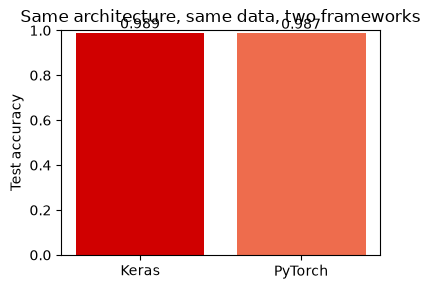


-> Two completely different code paths converged on comparable test accuracy --
   the theory that they implement the same math wasn't just asserted, it's measured above.


In [20]:
# --- Side-by-side check: did the two independently-trained models actually land in the same place? ---
pytorch_test_acc = correct / total  # `correct` and `total` are still in scope from the Section 6 eval loop above

print(f"Keras test accuracy:   {test_acc:.4f}")
print(f"PyTorch test accuracy: {pytorch_test_acc:.4f}")
print(f"Difference:            {abs(test_acc - pytorch_test_acc):.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(["Keras", "PyTorch"], [test_acc, pytorch_test_acc], color=["#d00000", "#ee6c4d"])
ax.set_ylim(0, 1)
ax.set_ylabel("Test accuracy")
ax.set_title("Same architecture, same data, two frameworks")
for bar, value in zip(bars, [test_acc, pytorch_test_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center")
plt.tight_layout()
plt.show()

print("\n-> Two completely different code paths converged on comparable test accuracy --")
print("   the theory that they implement the same math wasn't just asserted, it's measured above.")


## Saving and Loading Weights

**Keras:** `model.save("my_model.keras")` (whole model: architecture + weights + optimizer
state) or `model.save_weights("my_weights.h5")` (weights only) -- both are single-line calls,
and Keras knows how to reconstruct the model from the same file.

**PyTorch:** the idiomatic pattern is weights-only. `model.state_dict()` returns an ordered
dict of every learnable tensor by name, saved with `torch.save`. There's no built-in "reload
the architecture from the file" -- you re-instantiate the *same* `nn.Module` class yourself,
then call `load_state_dict()` to restore its weights. The cell below proves this with a real
round-trip: save `pytorch_model`'s weights, load them into a **freshly constructed,
randomly-initialized** `SimpleCNN`, and confirm its predictions on the same sample images now
match the trained model's exactly.



In [ ]:
# --- Round-trip proof: save pytorch_model's weights, load them into a fresh model, compare ---
import io

buffer = io.BytesIO()
torch.save(pytorch_model.state_dict(), buffer)  # weights only, not the class definition
print(f"Saved state_dict: {len(pytorch_model.state_dict())} tensors, {buffer.tell():,} bytes.")

# A brand-new, randomly-initialized model -- NOT a copy of pytorch_model
fresh_model = SimpleCNN().to(device)
fresh_model.eval()
with torch.no_grad():
    fresh_logits_before = fresh_model(sample_images)
fresh_preds_before = fresh_logits_before.argmax(dim=1).cpu()

buffer.seek(0)
fresh_model.load_state_dict(torch.load(buffer, weights_only=True))
fresh_model.eval()
with torch.no_grad():
    fresh_logits_after = fresh_model(sample_images)
fresh_preds_after = fresh_logits_after.argmax(dim=1).cpu()

print(f"\nFresh (random) model predictions:     {fresh_preds_before.tolist()}")
print(f"After load_state_dict(), predictions: {fresh_preds_after.tolist()}")
print(f"Original pytorch_model predictions:   {pred_labels.tolist()}")
assert torch.equal(fresh_preds_after, pred_labels), "Loaded weights should reproduce the trained model exactly."
print("\n-> Confirmed: load_state_dict() reproduced the trained model's exact predictions --")
print("   the architecture (the SimpleCNN class) and the weights (state_dict) are two separate")
print("   things in PyTorch, unlike Keras's single model.save() file.")


## Cheat Sheet: Keras -> PyTorch

| Keras concept                                                  | PyTorch equivalent                                                                                      |
| -------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| `keras.Sequential([...])`                                      | `class Model(nn.Module)` with layers in `__init__` + logic in `forward()`                               |
| Automatic input-shape inference                                | You compute and hard-code every layer's input size yourself                                             |
| `Dense(units)`                                                 | `nn.Linear(in_features, out_features)`                                                                  |
| `Conv2D(filters, kernel_size)`                                 | `nn.Conv2d(in_channels, out_channels, kernel_size)`                                                     |
| `MaxPooling2D(pool_size)`                                      | `nn.MaxPool2d(kernel_size)`                                                                             |
| `Flatten()`                                                    | `x.view(x.size(0), -1)` or `nn.Flatten()`                                                               |
| Data as NumPy arrays, shape `(N, H, W, C)` (**channels last**) | `Dataset` + `DataLoader`, shape `(N, C, H, W)` (**channels first**)                                     |
| `model.compile(optimizer=..., loss=..., metrics=...)`          | Create `criterion` and `optimizer` as separate objects; no `compile()` step                             |
| `model.fit(x, y, epochs=...)`                                  | Write the training loop yourself: `zero_grad()` -> forward -> `backward()` -> `step()`                  |
| `model.evaluate(x, y)`                                         | Manual loop with `model.eval()` + `torch.no_grad()`                                                     |
| `model.predict(x)`                                             | `model(x)` inside `torch.no_grad()`, after `model.eval()`                                               |
| `model.summary()`                                              | `print(model)` + manual `sum(p.numel() for p in model.parameters())`                                    |
| GPU used automatically if present                              | Explicit `.to(device)` on both the model and every batch of data                                        |
| Final `Dense(10, activation="softmax")`                        | Final `nn.Linear(..., 10)` returns raw logits; `nn.CrossEntropyLoss` applies the log-softmax internally |
| `model.save(...)` / `model.save_weights(...)`                  | `torch.save(model.state_dict(), path)` + `model.load_state_dict(torch.load(path))` on a re-instantiated class |

## Gotchas worth remembering

1. **Gradients accumulate.** Forgetting `optimizer.zero_grad()` silently corrupts training --
   there's no error, just worse accuracy.
2. **`model.train()` / `model.eval()` matter.** Any layer that behaves differently at train
   vs. inference time (dropout, batchnorm) needs the mode set explicitly, every time you
   switch between training and evaluating -- the dropout probe further up shows the two modes
   actually disagree, not just that the calls exist.
3. **`torch.no_grad()` isn't optional for eval/inference.** Skipping it still _works_, but
   wastes memory tracking gradients you'll never use.
4. **Channels-first, not channels-last.** `(C, H, W)`, not `(H, W, C)`. This is the #1 shape-mismatch
   bug when porting data pipelines between the two frameworks.
5. **Nothing moves to the GPU for you.** Both the model (`model.to(device)`) and every batch
   of data (`images.to(device)`) need an explicit `.to(device)` call.
6. **No automatic shape inference.** You compute conv-output and flatten sizes by hand (or
   use `nn.LazyLinear`/`nn.AdaptiveAvgPool2d` to sidestep it) -- Keras never makes you do this.
7. **Weights and architecture are saved separately.** `state_dict()` only holds tensors, not
   the class definition -- you need the original `nn.Module` class available to reload into.

## Next steps

Head to [`01-rnns/`](../01-rnns/) next -- it has the same PyTorch-vs-Keras pairing
(`PT_Part1_Intro.ipynb` and `TF_Part1_Intro-keras.ipynb`), now applied to recurrent networks
instead of a CNN. Everything in this primer's cheat sheet applies there too.


## What This Notebook Covered (and What It Didn't)

The **Roadmap -- completed** table right below has the full side-by-side list of what was
actually built and measured, pair by pair -- no need to repeat it here.

A couple of extra ideas got a quick illustration along the way, and a handful of related
topics were named but deliberately left out:

- **Illustrated with a short snippet, not a full section:** `train()`/`eval()` mode (the
  `nn.Dropout` probe), saving/loading weights (the `state_dict()` round-trip), and
  `nn.Sequential` as PyTorch's own lightweight equivalent to `keras.Sequential`.
- **Named, but out of scope:** `tf.GradientTape`, writing a custom `Dataset` subclass, data
  augmentation/transform pipelines, train/validation splitting inside a manual loop,
  learning-rate schedulers & Keras callbacks, weight-initialization defaults, and
  deployment/export tooling (`torch.jit`, `torch.onnx`).


## Roadmap -- completed

| Step | Concept | Confirmed by |
|---|---|---|
| 1 | Imports & seeding | Both frameworks printed their own version + device info from one seeding call each |
| 2 | Loading MNIST | Measured shapes showed channels-last vs. channels-first directly, not just described in prose |
| 3 | Defining the model | The hard-coded `64*5*5` flatten size was verified with a dummy forward pass, not taken on faith |
| 4 | Compile vs. loss + optimizer | Same `Adam(lr=1e-3)` and cross-entropy loss, just packaged differently |
| 5 | Training | The manual PyTorch loop matched `.fit()`'s behavior, and the zero_grad() ablation proved -- rather than asserted -- that skipping it hurts training |
| 6 | Evaluation | Both frameworks scored the same 10,000-image test set |
| 7 | Inference / prediction | Both models agreed on the same 8 sample digits |
| -- | Final check | Test accuracy compared side by side -- two different codebases, comparable numbers |

## Key insights to keep

- PyTorch never infers a shape for you: every `nn.Linear`/`nn.Conv2d` input size is a
  number you compute and hard-code, so verify it with a dummy forward pass instead of
  trusting your arithmetic.
- `model.fit()` and the four-line manual loop (`zero_grad -> forward -> backward -> step`)
  do the same work -- the manual version just makes every step visible and debuggable.
- "Gradients accumulate" isn't a trivia fact -- forgetting `zero_grad()` measurably raises
  the loss after the same number of steps, with no error message to warn you.
- Channels-first vs. channels-last is the single most common silent shape bug when porting
  a data pipeline between the two frameworks -- check `.shape` after loading, every time.
- Two independently trained models, one per framework, converging on comparable test
  accuracy is the real proof that "same math, different API" is true -- not just a
  reassuring sentence.

